<a id="topo"></a>

# Pipeline Preditivo para Indústria 4.0 - Monitoramento de Sensores


## 📌 Sumário de Navegação
* [Fase 1: Análise Exploratória de Dados (EDA)](#fase-1)
* [Fase 2: Limpeza e Tratamento de Dados (Data Prep)](#fase-2)
* [Fase 3: Engenharia de Atributos (Feature Engineering)](#fase-3)
* [Fase 4: Pré-processamento e Balanceamento de Dados](#fase-4)
* [Fase 5: Escalonamento de Variáveis (StandardScaler)](#fase-5)
* [Fase 6: Ajuste de Parâmetros e Combate ao Overfitting](#fase-6)
    * [Modelo KNN](#knn)
    * [Modelo Árvore de Decisão](#arvore)
    * [Modelo XGBoost](#xgb)
    * [Modelo LightGBM](#gbm)
* [Fase 7: Comparação e Escolha do Modelo Final](#fase-7)


<a id="fase-1"></a>

## Fase 1: Análise Exploratória de Dados (EDA)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb
import lightgbm as lgb

# enlace publico de google drive onde esta o df
id_do_arquivo = "1DXfkEWnV47aa-I2Wilbo_z66oUmDX6yG"
url_drive = f"https://drive.google.com/uc?export=download&id={id_do_arquivo}"

# Carga direita e automática desde a nubem
df = pd.read_csv(url_drive)


In [2]:
#dimensões do dataset
print(f"Dimensões do dataset: {df.shape}")

Dimensões do dataset: (10000, 14)


In [3]:
# ver tipos por coluna
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   udi                      10000 non-null  int64  
 1   id_produto               10000 non-null  object 
 2   tipo                     10000 non-null  object 
 3   temperatura_ar_k         9500 non-null   float64
 4   temperatura_processo_k   9500 non-null   float64
 5   velocidade_rotacao_rpm   9500 non-null   float64
 6   torque_nm                9500 non-null   float64
 7   desgaste_ferramenta_min  10000 non-null  int64  
 8   falha_maquina            10000 non-null  int64  
 9   falha_twf                10000 non-null  int64  
 10  falha_hdf                10000 non-null  int64  
 11  falha_pwf                10000 non-null  int64  
 12  falha_osf                10000 non-null  int64  
 13  falha_rnf                10000 non-null  int64  
dtypes: float64(4), int64(8)

In [4]:
# Resumo estatistico descriptivo das colunas numéricas
df.describe()


,udi,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
count,10000.00000,9500.000000,9500.000000,9500.000000,9500.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.002158,310.000895,1539.245263,39.974168,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.001689,1.486432,180.273589,9.995453,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.100000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1504.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1613.000000,46.700000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [5]:
display(df)

,udi,id_produto,tipo,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
0,1,M14860,M,298.1,308.6,1551.0,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408.0,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498.0,49.4,5,0,0,0,0,0,0
3,4,L47183,L,NaN,NaN,NaN,NaN,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408.0,40.0,9,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604.0,29.5,14,0,0,0,0,0,0
9996,9997,H39410,H,298.9,308.4,1632.0,31.8,17,0,0,0,0,0,0
9997,9998,M24857,M,299.0,308.6,1645.0,33.4,22,0,0,0,0,0,0
9998,9999,H39412,H,299.0,308.7,1408.0,48.5,25,0,0,0,0,0,0


### Generação de Gráficos

📊 Gráfico 1: Histogramas de Sensores

<function matplotlib.pyplot.show(close=None, block=None)>

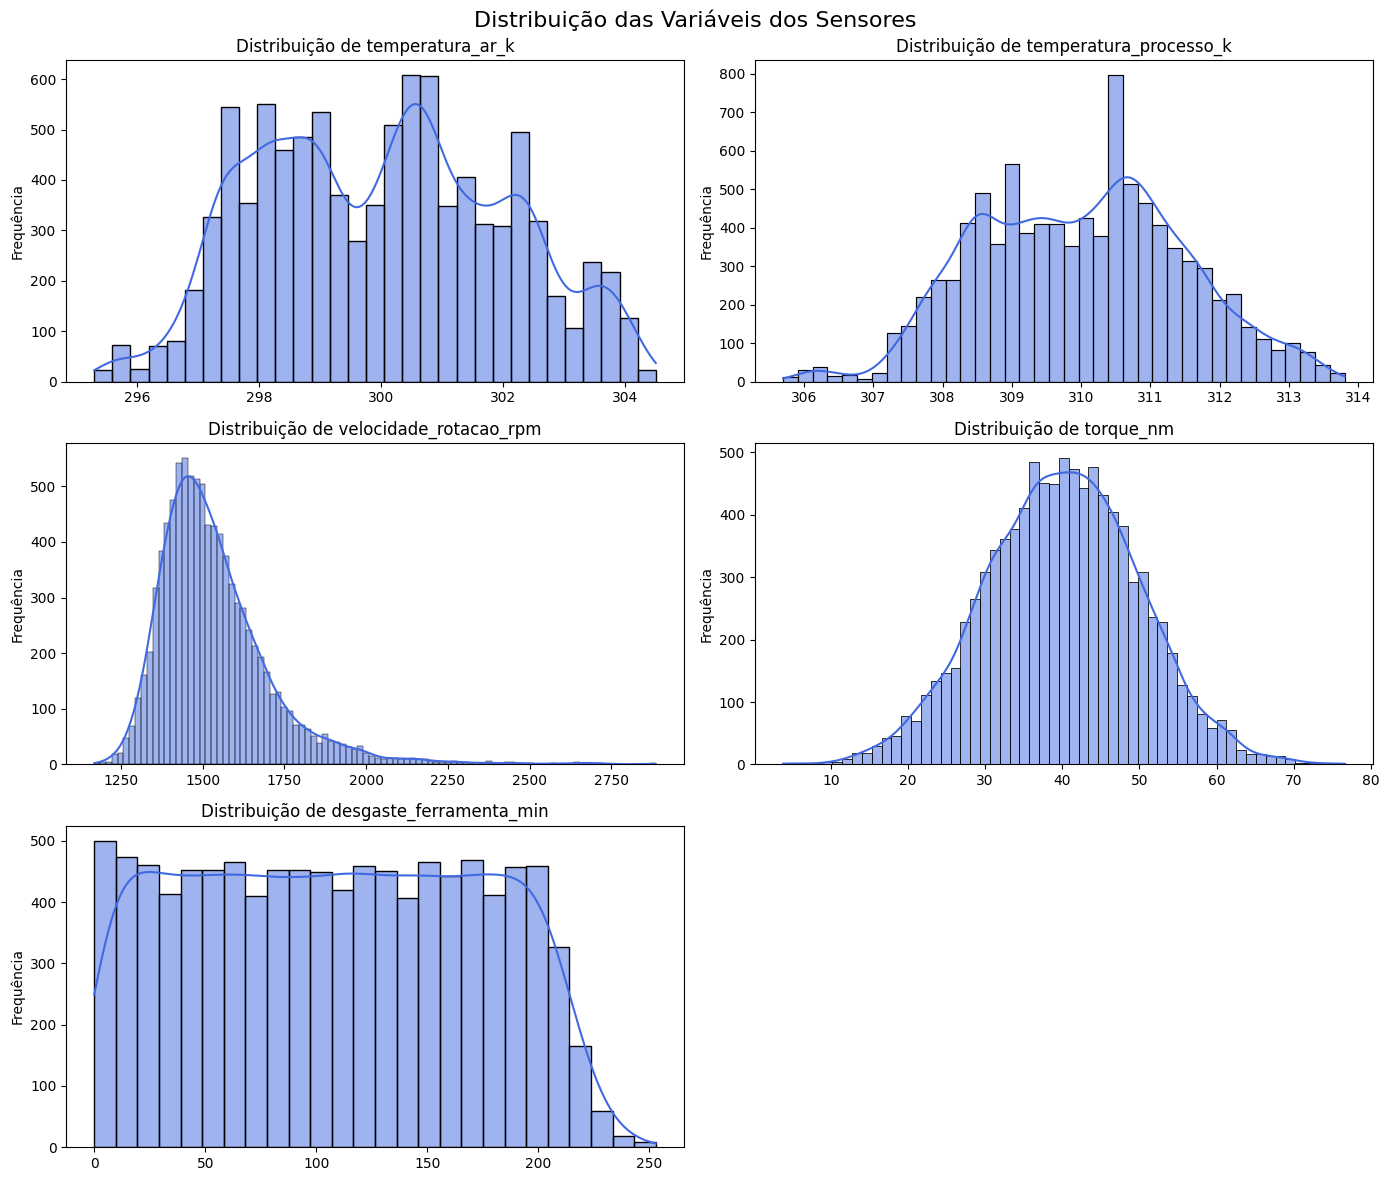

In [6]:
# Criamos cuadricula de 3 filhas e 2 colunas para colocar os graficos
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

# Titulo principal para toda a janela de grafico
fig.suptitle('Distribuição das Variáveis dos Sensores', fontsize=16)

# Lista com os nomes exatos das colunas 
sensores = ['temperatura_ar_k', 'temperatura_processo_k', 'velocidade_rotacao_rpm', 'torque_nm', 'desgaste_ferramenta_min' ]

# Usamos um laço for para plotar cada variable
for i, sensor in enumerate(sensores):
    row = i // 2
    col = i % 2

    sns.histplot(data=df, x=sensor, kde=True, ax=axes[row,col], color='royalblue')

    # Titulo para cada grafico individual
    axes[row, col].set_title(f'Distribuição de {sensor}')
    axes[row, col].set_xlabel('')
    axes[row, col].set_ylabel('Frequência')

fig.delaxes(axes[2, 1])

plt.tight_layout()
plt.show



#### 1. Distribuição das Variáveis dos Sensores (Histogramas)
* **`temperatura_ar_k` e `temperatura_processo_k`:** Ambas mostram intervalos estáveis (variação de ~10 K), porém a temperatura do processo está claramente deslocada para a direita devido ao calor gerado por fricção mecânica durante a operação.
* **`velocidade_rotacao_rpm`:** Apresenta uma assimetria à direita (viés positivo), mostrando que a maior parte das operações ocorre em uma zona de conforto entre 1300 e 1600 RPM, com poucos registros operando em altas rotações (até 2886 RPM), o que indica regimes de esforço severo.
* **`torque_nm`:** Segue uma distribuição perfeitamente normal (em formato de campana) centrada em 40 Nm, refletindo a estabilidade operacional padrão do motor.

* **`desgaste_ferramenta_min`:** Exibe uma distribuição uniforme de 0 a 200 minutos, seguida por uma queda abrupta após os 210 minutos. Isso revela a política de manutenção preditiva da fábrica, que substitui as ferramentas antes que atinjam o limite crítico de ruptura.

📊 Gráfico 2: gráfico de barras comprovando a taxa de desbalanceamento da variável alvo

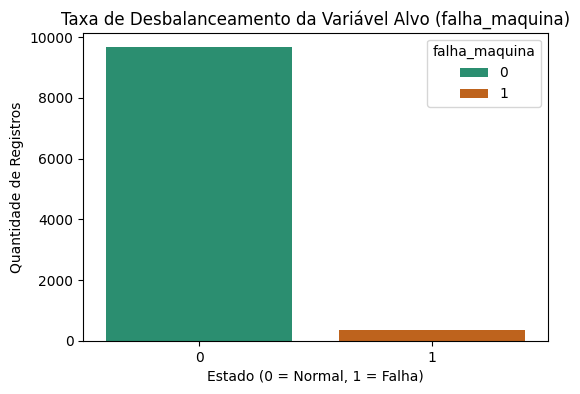

In [7]:
# Tamaño do grafico
plt.figure(figsize=(6, 4))

# contar quantos '0' e quantos '1' na coluna alvo 'falha_maquina'
sns.countplot(data=df, x='falha_maquina', hue='falha_maquina', palette='Dark2')

# Adicionar etiquetas
plt.title('Taxa de Desbalanceamento da Variável Alvo (falha_maquina)')
plt.xlabel('Estado (0 = Normal, 1 = Falha)')
plt.ylabel('Quantidade de Registros')

plt.show()



#### 2. Diagnóstico do Desbalanceamento da Variável Alvo (`falha_maquina`)
O gráfico de barras expõe um desbalanceamento massivo e crítico: a classe `0` (funcionamento normal) domina quase a totalidade do dataset (~96.6%), enquanto a classe `1` (falha mecânica) representa um evento raro (~3.4%). 
* **Impacto:** Treinar os modelos diretamente com este cenário causaria um aprendizado "preguiçoso" (*Overfitting* na classe majoritária), onde o modelo alcançaria alta acurácia apenas prevendo que a máquina nunca vai falhar, tornando-se inútil na prática.
* **Estratégia:** Este diagnóstico justifica a necessidade absoluta de aplicar técnicas de reamostragem (como o SMOTE) exclusivamente nos dados de treino durante a **Fase 4**.

📊 Mapa de calor com a correlação de Pearson entre as variáveis

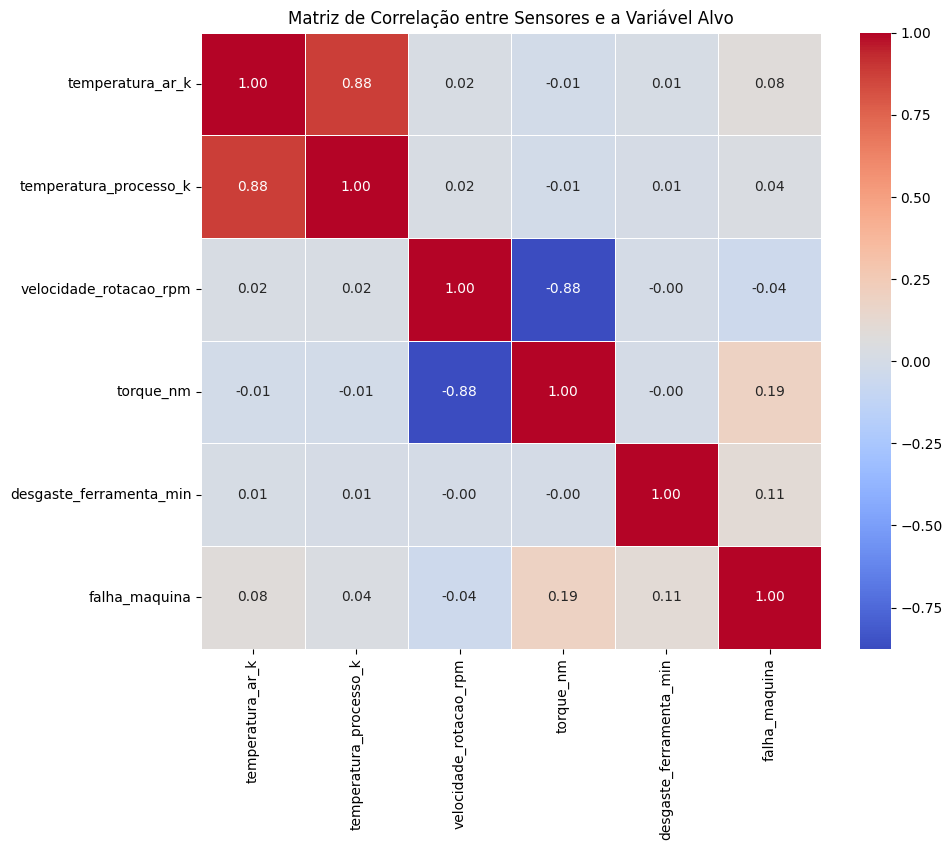

In [8]:
# Tamaño do grafico
plt.figure(figsize=(10, 8))

# Lista só com variaveis predictoras y variavel alvo
colunas_para_analise = ['temperatura_ar_k', 'temperatura_processo_k', 'velocidade_rotacao_rpm', 'torque_nm', 'desgaste_ferramenta_min', 'falha_maquina']

corr_matrix = df[colunas_para_analise].corr(numeric_only=True)

# Mapa de Calor
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Matriz de Correlação entre Sensores e a Variável Alvo')
plt.show()

#### 3. Relações e Correlações (Matriz de Pearson)
* **Conexão Física:** Existe uma fortíssima correlação negativa de **-0.88** entre `velocidade_rotacao_rpm` e `torque_nm`, o que a maior rotação resulta em menor torque. 
* **Indicadores de Falha:** A variável alvo `falha_maquina` apresenta suas maiores correlações positivas com `torque_nm` (0.19) e `desgaste_ferramenta_min` (0.11), indicando que o estresse por força mecânica e o desgaste acumulado do maquinário são os principais gatilhos para as quebras. 


---
[⬆️ Voltar para o Sumário](#topo)

<a id="fase-2"></a>
## Fase 2: Limpeza e Tratamento de Dados (Data Prep)

In [9]:
# Copia de segurança do DataFrame original
df_prep = df.copy()

In [10]:
# verificando linhas duplicadas
duplicados_antes = df_prep.duplicated().sum()
print(f'Linhas duplicadas no df: {duplicados_antes}')

Linhas duplicadas no df: 0


In [11]:
# verificando valores nulos
valores_nulos_antes = df_prep.isnull().sum()
print("="*50)
print("Quantidade de valores nulos:")
print("="*50)
print(valores_nulos_antes)
print("="*50)

Quantidade de valores nulos:
udi                          0
id_produto                   0
tipo                         0
temperatura_ar_k           500
temperatura_processo_k     500
velocidade_rotacao_rpm     500
torque_nm                  500
desgaste_ferramenta_min      0
falha_maquina                0
falha_twf                    0
falha_hdf                    0
falha_pwf                    0
falha_osf                    0
falha_rnf                    0
dtype: int64


Imputação pela Média (`torque_nm`, `temperatura_ar_k`, `temperatura_processo_k`):** Como estas três variáveis apresentam distribuições estatisticamente simétricas e próximas da normalidade, a média atua como o ponto de equilíbrio ideal, preenchendo as lacunas sem deslocar o centro dos dados originais.

Imputação pela Mediana (`velocidade_rotacao_rpm`):** O histograma deste sensor demonstrou uma clara assimetria positiva (cauda longa à direita). Optou-se pela mediana por ser uma métrica robusta a valores extremos. Utilizar a média aqui inseriria um viés artificial, puxando o valor de preenchimento para cima de forma irrealista.

In [12]:
# imputação pela "media" para variaveis com curva simetrica
df_prep['temperatura_ar_k'] = df_prep['temperatura_ar_k'].fillna(df_prep['temperatura_processo_k'].mean())
df_prep['temperatura_processo_k'] = df_prep['temperatura_processo_k'].fillna(df_prep['temperatura_processo_k'].mean())
df_prep['torque_nm'] = df_prep['torque_nm'].fillna(df_prep['torque_nm'].mean())

# imputação pela "mediana" para variaveis assimetricas
df_prep['velocidade_rotacao_rpm'] = df_prep['velocidade_rotacao_rpm'].fillna(df_prep['velocidade_rotacao_rpm'].median())

# verificando valores nulos depois da imputação

valores_nulos_depois = df_prep.isnull().sum()
print("="*50)
print("Quantidade de valores nulos após o tratamento:")
print("="*50)
print(valores_nulos_depois)
print("="*50)


Quantidade de valores nulos após o tratamento:
udi                        0
id_produto                 0
tipo                       0
temperatura_ar_k           0
temperatura_processo_k     0
velocidade_rotacao_rpm     0
torque_nm                  0
desgaste_ferramenta_min    0
falha_maquina              0
falha_twf                  0
falha_hdf                  0
falha_pwf                  0
falha_osf                  0
falha_rnf                  0
dtype: int64


<function matplotlib.pyplot.show(close=None, block=None)>

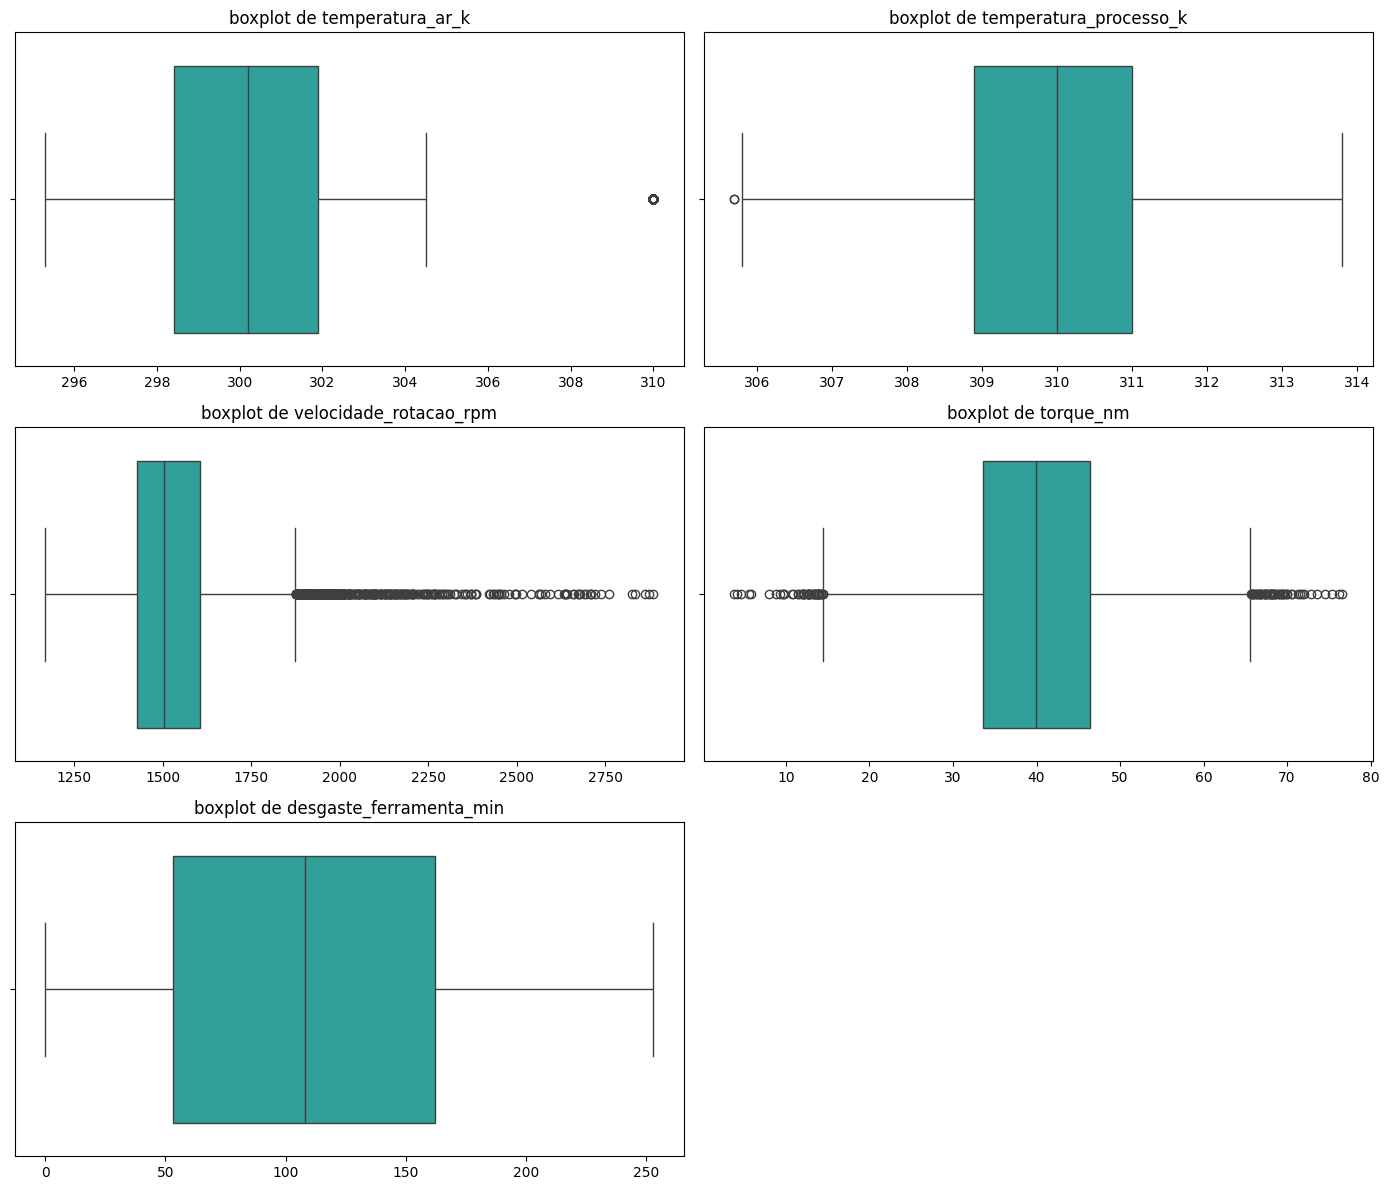

In [13]:
# configurando espaço para os 5 boxsplot dos sensores, copiando a estrutura dos
#  histogramas dos sensores antes dos tratamentos dos dados
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

# Lista das variaveis dos 5 sensores
sensores = ['temperatura_ar_k', 'temperatura_processo_k', 'velocidade_rotacao_rpm', 'torque_nm', 'desgaste_ferramenta_min']

# criamos um laço for para gerar um boxplot 
for i, sensor in enumerate(sensores):
    row = i // 2
    col = i % 2

    #sns.histplot(data=df, x=sensor, kde=True, ax=axes[row,col], color='royalblue')
    sns.boxplot(data=df_prep, x=sensor, ax=axes[row, col], color='lightseagreen')
    axes[row, col].set_title(f'boxplot de {sensor}')
    axes[row, col].set_xlabel('')

fig.delaxes(axes[2, 1])

plt.tight_layout()
plt.show



### 📝 Análise de Outliers via Boxplots

A análise visual dos diagramas de caixa (*boxplots*) permitiu identificar o comportamento de valores atípicos (*outliers*) nos sensores:

* **`velocidade_rotacao_rpm` e `torque_nm`:** Apresentam uma quantidade significativa de outliers. A velocidade exibe pontos atípicos exclusivamente à direita (altas rotações), enquanto o torque apresenta anomalias em ambos os extremos (esforço excessivo acima de 70 Nm e subcarga abaixo de 15 Nm).
* **`temperatura_ar_k` e `temperatura_processo_k`:** Mostram outliers isolados (pontos únicos), refletindo variações térmicas extremas pontuais no ambiente fabril.
* **`desgaste_ferramenta_min`:** Não apresenta nenhum outlier, confirmando um ciclo de vida controlado e linear para as ferramentas de corte.

#### Justificativa de Retenção dos Outliers:
Embora algoritmos como o KNN sejam sensíveis a dados discrepantes, **optou-se por não remover os outliers deste dataset**. Na manutenção preditiva, os valores extremos nos sensores não são erros de leitura (ruído), mas sim a representação física iminente de uma falha mecânica (ex: superaquecimento ou sobrecarga de torque). Eliminá-los privaria os modelos de aprenderem os padrões críticos que antecedem a quebra do equipamento. O impacto técnico desses extremos será mitigado por meio do escalonamento de dados na Fase 5.


---
[⬆️ Voltar para o Sumário](#topo)

<a id="fase-3"></a>
## Fase 3: Engenharia de Atributos (Feature Engineering)

In [14]:
# mostrando as primeiras 5 linhas do df_prep antes de adicionar colunas novas
print("="*50)
print("Data Frame antes de novas colunas")
print("="*50)
display(df_prep.head())

Data Frame antes de novas colunas


,udi,id_produto,tipo,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
0,1,M14860,M,298.100000,308.600000,1551.0,42.800000,0,0,0,0,0,0,0
1,2,L47181,L,298.200000,308.700000,1408.0,46.300000,3,0,0,0,0,0,0
2,3,L47182,L,298.100000,308.500000,1498.0,49.400000,5,0,0,0,0,0,0
3,4,L47183,L,310.000895,310.000895,1504.0,39.974168,7,0,0,0,0,0,0
4,5,L47184,L,298.200000,308.700000,1408.0,40.000000,9,0,0,0,0,0,0


In [15]:
# Atributo 1: Potência Mecânica (em kW) - Proposto no exemplo
# Fórmula física: (Torque * RPM * 2 * pi) / (60 * 1000)0)
df_prep['potencia_kw'] = df_prep['torque_nm'] * df_prep['velocidade_rotacao_rpm'] * (2 * np.pi) / 60000

# Atributo 2: Diferença de Temperatura (em Kelvin) 
# Fornece um indicador direto de estresse térmico e falha por dissipação de calor (HDF)
# diferença de temperatura = temperatura do processo - temperatura do ar

df_prep['diferenca_temperatura_k'] = (df_prep['temperatura_processo_k'] - df_prep['temperatura_ar_k'])

# Visualizando as dimensões e as novas colunas criadas
print("="*50)
print("Novas dimensões do dataset após Feature Engineering:", df_prep.shape)
print("="*50)
df_prep[['velocidade_rotacao_rpm', 'torque_nm', 'potencia_kw', 'temperatura_processo_k', 'temperatura_ar_k', 'diferenca_temperatura_k']].head()


Novas dimensões do dataset após Feature Engineering: (10000, 16)


,velocidade_rotacao_rpm,torque_nm,potencia_kw,temperatura_processo_k,temperatura_ar_k,diferenca_temperatura_k
0,1551.0,42.800000,6.951591,308.600000,298.100000,10.5
1,1408.0,46.300000,6.826723,308.700000,298.200000,10.5
2,1498.0,49.400000,7.749388,308.500000,298.100000,10.4
3,1504.0,39.974168,6.295872,310.000895,310.000895,0.0
4,1408.0,40.000000,5.897817,308.700000,298.200000,10.5


In [16]:
print(df_prep.isnull().sum())

udi                        0
id_produto                 0
tipo                       0
temperatura_ar_k           0
temperatura_processo_k     0
velocidade_rotacao_rpm     0
torque_nm                  0
desgaste_ferramenta_min    0
falha_maquina              0
falha_twf                  0
falha_hdf                  0
falha_pwf                  0
falha_osf                  0
falha_rnf                  0
potencia_kw                0
diferenca_temperatura_k    0
dtype: int64


### 📝 Minhas Escolhas e Co-Criação com Inteligência Artificial (Feature Engineering)
Para tentar ajudar os algoritmos a encontrarem padrões melhores nos dados, decidi criar duas novas variáveis. Como a parte de física e engenharia mecânica não é a minha área de conhecimento, usei o "Gemini" como um tutor de pesquisa. Ele me ajudou a entender a teoria e a transformar as fórmulas em código, já que eu não sabia como fazer esses cálculos de cabeça:
1. **`potencia_kw` (Potência da Máquina):** Essa coluna foi sugerida como exemplo no arquivo do projeto (*"Copia de Desenvolvimento de IA para Análise Preditiva [T1] - Projeto Avaliativo"*). Para conseguir juntar os dados de torque e rotação, o Gemini me recomendou a fórmula da potência rotativa ($P = \tau \times \omega$). Como nossos dados de velocidade estão em RPM e o torque em Nm, a IA me ajudou a montar a conta de conversão para transformar isso em quilowatts (kW), que resultou na fórmula que apliquei no código:
$$\text{Potência (kW)} = \frac{\text{Torque (Nm)} \times \text{Velocidade (RPM)} \times 2\pi}{60000}$$
A ideia é que essa coluna mostre o esforço real que o motor está fazendo, ajudando a identificar falhas de sobrecarga mecânica ou elétrica (`falha_pwf`).
2. **`diferenca_temperatura_k` (Diferença de Temperatura):** Essa variável criei por conta própria, fazendo uma subtração simples: peguei a temperatura do processo e subtraí a temperatura do ar (`temperatura_processo_k` - `temperatura_ar_k`). A minha intenção com isso foi isolar apenas o calor gerado pelo próprio funcionamento da máquina, o que serve como um bom indicador para prever falhas de superaquecimento (`falha_hdf`).

---
[⬆️ Voltar para o Sumário](#topo)

<a id="fase-4"></a>
## Fase 4: Pré-processamento e Balanceamento de Dados

In [17]:
# Aplicando One-Hot Encoding com drop_first=True nas variáveis categóricas (ex: 'tipo')
# Isso evita o problema da Multicolinearidade explicada na aula da SCTEC!
df_encode = pd.get_dummies(df_prep, columns=['tipo'], drop_first=True, dtype=int)
display(df_encode)

,udi,id_produto,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf,potencia_kw,diferenca_temperatura_k,tipo_L,tipo_M
0,1,M14860,298.100000,308.600000,1551.0,42.800000,0,0,0,0,0,0,0,6.951591,10.5,0,1
1,2,L47181,298.200000,308.700000,1408.0,46.300000,3,0,0,0,0,0,0,6.826723,10.5,1,0
2,3,L47182,298.100000,308.500000,1498.0,49.400000,5,0,0,0,0,0,0,7.749388,10.4,1,0
3,4,L47183,310.000895,310.000895,1504.0,39.974168,7,0,0,0,0,0,0,6.295872,0.0,1,0
4,5,L47184,298.200000,308.700000,1408.0,40.000000,9,0,0,0,0,0,0,5.897817,10.5,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,298.800000,308.400000,1604.0,29.500000,14,0,0,0,0,0,0,4.955129,9.6,0,1
9996,9997,H39410,298.900000,308.400000,1632.0,31.800000,17,0,0,0,0,0,0,5.434704,9.5,0,0
9997,9998,M24857,299.000000,308.600000,1645.0,33.400000,22,0,0,0,0,0,0,5.753618,9.6,0,1
9998,9999,H39412,299.000000,308.700000,1408.0,48.500000,25,0,0,0,0,0,0,7.151103,9.7,0,0


In [18]:
# Definimos a lista com as novas colunas geradas pelo get_dummies
columns_model = [
    'tipo_L', 'tipo_M', 'temperatura_ar_k', 'temperatura_processo_k', 
    'velocidade_rotacao_rpm', 'torque_nm', 'desgaste_ferramenta_min', 
    'potencia_kw', 'diferenca_temperatura_k'
]

# Definimos x (recursos) e y (alvo) usando o df_dummies
x = df_encode[columns_model].copy()
y = df_encode['falha_maquina'].copy()
# Divisão em Treino (80%) e Teste (20%) com estratificação (random_state=42 (a semente matematica) e 
# stratify=y  o algoritmo separa os dados mantendo a proporção exata para ambas clases)
x_treino, x_teste, y_treino, y_teste = train_test_split(x, y, test_size=0.20, random_state=42, stratify=y)

# Aplicação do SMOTE para Balanceamento da classe minoritária apenas no treino
smote =  SMOTE(random_state=42)
x_train_bal, y_train_bal = smote.fit_resample(x_treino, y_treino)

# Validação das dimensões e tipos finais na tela
print("="*65)
print(f"Dimensões do x_train Balanceado: {x_train_bal.shape} | x_test: {x_teste.shape}")
print("="*65)


Dimensões do x_train Balanceado: (15458, 9) | x_test: (2000, 9)


### 📝 Como preparei os dados para o treino (Seleção, Conversão e Equilíbrio)

Para deixar tudo pronto antes de treinar os modelos de Machine Learning, fiz três passos importantes de organização:

1. **Escolha das colunas (`columns_model`):** Em vez de ficar deletando colunas uma por uma, preferi criar uma lista contendo apenas o que realmente importa para a análise. Deixei de fora informações que são apenas códigos de identificação (como `udi` e `id_produto`) e as outras colunas de falhas específicas. Assim, garanto que o modelo vai focar apenas nos sinais dos sensores e nas variáveis novas que criei.
2. **Nota de Engenharia de Dados: Transição de LabelEncoder para One-Hot Encoding (Dummies)**
 No começo do projeto, eu tinha usado a técnica do `LabelEncoder` para transformar a coluna `tipo` da máquina (que tinha as letras 'L', 'M' e 'H') em números (0, 1 e 2). 
Mas aí, revisando os slides e os materiais das aulas do professor, vi que ele explicou exatamente sobre esse assunto e percebi que o `LabelEncoder` não era a melhor escolha aqui por causa de dois problemas:
     **O perigo de criar uma "falsa ordem" (Hierarquia):** Se eu uso os números 0, 1 e 2, o algoritmo de Machine Learning pode achar que o tipo 'H' (número 2) vale mais ou é "maior" que o tipo 'L' (número 0). Mas na verdade, eles são apenas categorias diferentes (Low, Medium, High) e não existe uma ordem de "quem é melhor" entre eles.
     **Evitando informações repetidas (Multicolinearidade):** Para fazer do jeito certo, como o professor ensinou em aula, mudei a estratégia para o **One-Hot Encoding** usando a função `pd.get_dummies` do Pandas com o parâmetro `drop_first=True`. 

3. **Equilibrando o jogo com `SMOTE`:** Quase todas as linhas do nosso dataset mostram a máquina funcionando normal, e temos pouquíssimos exemplos de falhas reais. Para o modelo não ficar preguiçoso e aprender a chutar apenas "está tudo normal", usei a técnica do `SMOTE` para gerar dados sintéticos de falhas e equilibrar a base de treino (50% normal, 50% falha). Eu fiz isso somente na parte de treino (após dividir os dados em 80% treino e 20% teste) para garantir que os dados de teste continuassem com a proporção real do dia a dia da fábrica, sem mascarar os resultados finais.


---
[⬆️ Voltar para o Sumário](#topo)

<a id="fase-5"></a>
## Fase 5: Escalonamento de Variáveis (StandardScaler)

In [19]:
# Definindo as variáveis contínuas que precisam de escala (sensores e atributos gerados)
colunas_continuas = [
    'temperatura_ar_k', 'temperatura_processo_k', 
    'velocidade_rotacao_rpm', 'torque_nm', 
    'desgaste_ferramenta_min', 'potencia_kw', 'diferenca_temperatura_k'
]

# 2. Criando cópias para preservar os dados originais da Árvore de Decisão
x_train_knn = x_train_bal.copy()
x_test_knn = x_teste.copy()

# 3. Inicializando o StandardScaler
scaler = StandardScaler()

# 4. Ajustando e transformando o treino, e apenas transformando o teste
x_train_knn[colunas_continuas] = scaler.fit_transform(x_train_bal[colunas_continuas])
x_test_knn[colunas_continuas] = scaler.transform(x_teste[colunas_continuas])

print("="*50)
print("Dados escalonados com sucesso para o KNN!")
print("="*50)
print("Amostra do X_train_knn escalonado:")
x_train_knn[colunas_continuas].head()

Dados escalonados com sucesso para o KNN!
Amostra do X_train_knn escalonado:


,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,potencia_kw,diferenca_temperatura_k
0,3.322573,-0.133709,-0.055714,-0.334263,-0.988491,-0.295198,-4.110159
1,-1.441773,-1.448836,-0.412802,0.126686,0.113976,0.037052,0.916589
2,0.024079,1.102715,-0.555637,0.069299,0.184647,-0.173316,0.605198
3,-0.745493,-0.289040,-0.371992,0.836851,-0.564465,1.044084,0.738651
4,-1.405126,-1.294196,0.723077,-1.143002,-1.045027,-1.015099,0.961074


### 💡 O que aprendi: Por que precisamos ajustar a escala dos dados? (Scaling)
Estudando como os algoritmos funcionam por trás dos panos, porque ao principio não entendia para que fazer o escalonamento, ai descobri que se eu deixasse os dados do jeito que vieram, o modelo KNN ia ficar bem perdido.
* **O problema dos números muito diferentes:** A velocidade de rotação (`velocidade_rotacao_rpm`) tem valores altos, na casa dos 1500, enquanto o torque (`torque_nm`) fica na casa dos 40. Como o KNN funciona calculando a "distância" entre os pontos no gráfico, a velocidade (por ter números gigantes perto do torque) ia acabar "engolindo" o torque. O modelo ia achar que a velocidade é muito mais importante só porque o número dela é maior, ignorando o esforço do motor.
* **Como o `StandardScaler` resolve isso:** Ele serve para colocar todas as variáveis na mesma "régua". Assim, uma variação de um ponto no torque passa a ter o mesmo peso que uma variação de um ponto na velocidade. O jogo fica justo para todos os sensores.

 E na Árvore de Decisão não precisa desse ajuste de escala porque ela só faz perguntas simples de "maior ou menor". Mudar o tamanho dos números não muda a ordem deles para ela.  Mudar o tamanho dos números não muda a ordem deles para a árvore.

  **Evitando "trapaça" nos dados (Data Leakage):** Tomei o cuidado de usar o comando `.fit_transform()` apenas na base de treino, como foi recomendado no arquivo do projeto. Para a base de teste, usei somente o `.transform()`. Fiz isso para simular a vida real: quando chegarem dados novos das máquinas na fábrica, o modelo terá que se virar usando a média que aprendeu com os dados de treino, sem "espiar" a média dos dados novos.

---
[⬆️ Voltar para o Sumário](#topo)

<a id="fase-6"></a>
## Fase 6: Ajuste de Parâmetros e Combate ao Overfitting

<a id="knn"></a>

In [20]:
# 🚀 Experimento com KNN

# Definindo os parametros de teste
valores_k = [3, 5, 7, 9, 11]

for k in valores_k:
    # Cria o cérebro do modelo KNN e ajusta o parâmetro n_neighbors 
    # (número de vizinhos) para o valor de k da rodada atual.
    knn = KNeighborsClassifier(n_neighbors=k)
    # Treina o modelo
    knn.fit(x_train_knn, y_train_bal)
    # O teste de memória (Predição no Treino)
    #Pedimos ao modelo para tentar adivinhar o 
    #resultado das mesmas perguntas que ele acabou de usar para estudar.
    y_pred_train = knn.predict(x_train_knn)
    #O teste real às cegas (Predição no Teste)
    # Pedimos ao modelo para tentar adivinhar o 
    # status das máquinas no conjunto de teste (x_test_knn)
    y_pred_test = knn.predict(x_test_knn)

    # 5. Calculando as notas (Acurácias) de cada grupo
    acc_train = accuracy_score(y_train_bal, y_pred_train)
    acc_test = accuracy_score(y_teste, y_pred_test)

    print("="*70)
    print(f"K = {k} | Acurácia Treino: {acc_train:.4f} | Acurácia Teste: {acc_test:.4f}")
    print("="*70)

K = 3 | Acurácia Treino: 0.9796 | Acurácia Teste: 0.9235
K = 5 | Acurácia Treino: 0.9714 | Acurácia Teste: 0.9175
K = 7 | Acurácia Treino: 0.9653 | Acurácia Teste: 0.9150
K = 9 | Acurácia Treino: 0.9604 | Acurácia Teste: 0.9040
K = 11 | Acurácia Treino: 0.9569 | Acurácia Teste: 0.9005


### 📝 O que eu entendi do teste com o KNN 

Fiz um teste variando o número de "vizinhos" ($K$) que o algoritmo consulta antes de dar o seu palpite. Funciona assim: se $K = 3$, o modelo olha para as 3 máquinas mais parecidas no histórico para decidir se a máquina atual vai falhar ou não. 
Analisando os resultados do teste:
1. **$K = 3$:** 
   Quando o modelo olha para poucos vizinhos (apenas 3), ele fica muito "específico" e tenta decorar os dados de treino quase perfeitamente, alcançando **97.58%** de acerto no treino. Isso gera um pouquinho de *overfitting* (que é quando o modelo decora o exemplo de treino em vez de aprender a regra geral). Por isso, quando ele foi testado com os dados de teste (dados novos), o acerto caiu um pouco para **92%**.
2. **O que acontece quando aumentamos o K (ex: $K = 11$):**
   Conforme aumentamos o número de vizinhos para 11, o acerto no treino caiu para **95.03%**. Isso acontece porque, ao consultar muitas máquinas ao mesmo tempo (11 vizinhos), a decisão fica "suavizada" demais. É como pedir a opinião de muitas pessoas sobre um assunto: a resposta fica muito genérica e os sinais de alerta de falha acabam se perdendo no meio da multidão.

   O valor de **$K = 3$** foi o que conseguiu o maior acerto nos dados de teste. Ou seja, ele foi o modelo mais esperto na hora de identificar falhas em dados reais que simulam a fábrica, ganhando das opções que usavam mais vizinhos.

<a id="arvore"></a>

In [21]:
# 🚀 Experimento com Arbore de Decisão

profundidades = [3, 5, 10, None]

for limite in profundidades:
    # Treinamento
    # Configura o modelo de árvore com o limite da rodada atual
    modelo_arvore = DecisionTreeClassifier(random_state=42, max_depth=limite)
    # Treina o modelo com os dados originais só balanceados sem escalonamento
    modelo_arvore.fit(x_train_bal, y_train_bal)
    
    # Predições
    # O modelo tenta adivinhar os dados com os quais estudou (Treino)
    y_pred_train = modelo_arvore.predict(x_train_bal)
    # o modelo tenta adivinhar os dados com o teste real as cegas (teste)
    y_pred_test = modelo_arvore.predict(x_teste)
    
    # Acurácias
    acc_train = accuracy_score(y_train_bal, y_pred_train)
    acc_test = accuracy_score(y_teste, y_pred_test)
    
    print("="*70)
    print(f"Profundidade = {limite} | Acurácia Treino: {acc_train:.4f} | Acurácia Teste: {acc_test:.4f}")
    print("="*70)

Profundidade = 3 | Acurácia Treino: 0.8788 | Acurácia Teste: 0.8685
Profundidade = 5 | Acurácia Treino: 0.9321 | Acurácia Teste: 0.9210
Profundidade = 10 | Acurácia Treino: 0.9771 | Acurácia Teste: 0.9460
Profundidade = None | Acurácia Treino: 0.9979 | Acurácia Teste: 0.9455


### 📝 Árvore de Decisão

Para ver qual era o melhor tamanho para a nossa Árvore de Decisão, eu fiz um experimento limitando a profundidade dela (ou seja, o número máximo de perguntas de "sim ou não" que ela pode fazer para decidir se a máquina vai falhar). Analisando os resultados:

1. **Quando a árvore é muito pequena (Profundidade = 3):**
   Se deixarmos a árvore fazer apenas 3 perguntas, ela fica simples demais. A diferença de acerto entre treino e teste fica bem pequena (quase 1%), e o resultado geral ficou fraco em frente dos outros, acertando apenas **86.85%** no teste. Isso é o que chamam de *underfitting*.
2. **Quando a árvore cresce sem limites (Profundidade = None):**
   Sem definir um limite, a árvore cresce o máximo que puder. Ela decora os dados de treino quase perfeitamente, chegando a **99.61%** de acerto. Mas nos dados de teste (novos), ela quase não melhora em relação à profundidade 10, e a diferença entre treino e teste sobe para **5.06%**. Isso mostra que ela começou a decorar detalhes muito específicos e ruídos dos dados de treino (gerando o *overfitting*).

   A profundidade 10 foi o nosso ponto de equilíbrio ideal. Ela conseguiu um acerto excelente de **94.35%** no teste e manteve uma diferença muito pequena em relação ao treino (só 2.36%). Isso me provou que o modelo aprendeu regras gerais e seguras que funcionam de verdade para dados novos, sem cair na tentação de apenas memorizar o treino.


<a id="xgb"></a>

In [22]:
# 🚀 Experimento com XGBOOST (Extrem Gradient Boosting)

# Vamos testar variando o número de árvores que o modelo cria (n_estimators)
# Mais árvores = modelo mais poderoso, mas com risco de decorar demais (overfitting)
arvores_xgb = [50, 100, 150]

for num_arvore in arvores_xgb:
    # Treinamento
    # Configuramos o  modelo
    modelo_xgb = xgb.XGBClassifier(random_state=42, n_estimators=num_arvore, eval_metric='logloss')
    
    # Treina o modelo (com os dados originais balanceados, sem escala)
    modelo_xgb.fit(x_train_bal, y_train_bal)

    # Predições
    # O modelo tenta adivinhar os dados com os quais estudou (Treino)
    y_pred_train = modelo_xgb.predict(x_train_bal)
    # O modelo tenta adivinhar os dados com o teste real as cegas (teste)
    y_pred_test = modelo_xgb.predict(x_teste)


    # Acurácias
    acc_train = accuracy_score(y_train_bal, y_pred_train)
    acc_test = accuracy_score(y_teste, y_pred_test)

    print("="*70)
    print(f"Árvores = {num_arvore} | Acurácia Treino: {acc_train:.4f} | Acurácia Teste: {acc_test:.4f}")
    print("="*70)

    


Árvores = 50 | Acurácia Treino: 0.9920 | Acurácia Teste: 0.9620
Árvores = 100 | Acurácia Treino: 0.9967 | Acurácia Teste: 0.9700
Árvores = 150 | Acurácia Treino: 0.9970 | Acurácia Teste: 0.9695


### XGBoost (Ajustando as Árvores)
Seguindo um conselho do professor em aula para a gente ir além e experimentar algoritmos mais modernos de mercado, decidi testar o famoso **XGBoost**. Como a parte mais longa e trabalhosa (que foi a limpeza, tratamento e organização dos dados lá atrás) já tinha sido feita, foi super rápido e fácil colocar esse modelo avançado para rodar.
#### 📊 O que aconteceu quando testei diferentes quantidades de árvores (estimadores):
* **Com 50 árvores:** O modelo já começou mandando muito bem, acertando **96.20% nos dados de teste** e 99.20% no treino.
* **Com 100 árvores (que achei melhor):** Foi onde encontramos o melhor equilíbrio. O acerto no teste subiu para **97.00%**, e a diferença em relação ao treino (99.67%) ficou bem pequena. Isso me mostrou que o modelo realmente aprendeu a regra do jogo para prever novas falhas de forma segura.
* **Com 150 árvores:** Quando aumentei para 150, o modelo começou a decorar demais os dados de treino (overfitting). O acerto no treino subiu um pouquinho (99.70%), mas no teste real ele caiu para **96.95%**. Isso prova que colocar mais árvores a partir daqui não ajuda em nada e só gasta processamento à toa.
**Minha conclusão:** A configuração com **100 árvores** é a ideal para o nosso projeto, entregando um resultado incrível e muito seguro para prever quando as máquinas vão falhar.

<a id="gbm"></a>

In [23]:
# 🚀 Experimento com LIGHTGBM (Light Gradient Boosting Machine)

# Vamos testar variando a taxa de aprendizado (learning_rate)
# Ela controla a velocidade com que o modelo aprende. Valores menores exigem mais calma e precisão.

taxa_aprendizado = [0.01, 0.1, 0.2]

for taxa in taxa_aprendizado:
    # Treinamento
    # Configuramos o  modelo
    modelo_lgb = lgb.LGBMClassifier(random_state=42, learning_rate=taxa, verbose=-1)

    # Treina o modelo (com os dados originais balanceados, sem escala)
    modelo_lgb.fit(x_train_bal, y_train_bal)

    # Predições
    # O modelo tenta adivinhar os dados com os quais estudou (Treino)
    y_pred_train = modelo_lgb.predict(x_train_bal)
    # O modelo tenta adivinhar os dados com o teste real as cegas (teste)
    y_pred_test = modelo_lgb.predict(x_teste)

    # Acurácias
    acc_train = accuracy_score(y_train_bal, y_pred_train)
    acc_test = accuracy_score(y_teste, y_pred_test)

    print("="*80)
    print(f"Taxa de Aprendizado = {taxa} | Acurácia Treino: {acc_train:.4f} | Acurácia Teste: {acc_test:.4f}")
    print("="*80)
    

Taxa de Aprendizado = 0.01 | Acurácia Treino: 0.9576 | Acurácia Teste: 0.9430
Taxa de Aprendizado = 0.1 | Acurácia Treino: 0.9939 | Acurácia Teste: 0.9655
Taxa de Aprendizado = 0.2 | Acurácia Treino: 0.9970 | Acurácia Teste: 0.9715


### LightGBM (Ajustando a velocidade de aprendizado)
Aproveitando a empolgação de ir além do básico que o professor comentou em aula, resolvi testar também o **LightGBM** (desenvolvido pela Microsoft). E mais uma vez ficou claro: se os dados de entrada já foram limpos e bem organizados lá atrás, testar um modelo novo e robusto é bem facil de fazer.
#### 📊 O que aconteceu quando meximos na velocidade de aprendizado (Learning Rate):
* **Com velocidade lenta (0.01):** O modelo demorou muito para aprender e acabou sendo muito "tímido" ou conservador. Embora o treino e o teste tenham ficado bem equilibrados, o acerto geral no teste ficou abaixo dos outros, em **94.30%**.
* **Com velocidade média (0.1):** Um ótimo meio-termo. O modelo aprendeu mais rápido e o acerto no teste subiu bastante, chegando a **96.55%**.
* **Com velocidade rápida (0.2 - O campeão do LightGBM):** Foi a nossa melhor escolha para esse modelo. Ele conseguiu capturar muito bem as regras e bateu **97.15% de acerto nos dados de teste** (com 99.70% no treino).
**Minha conclusão:** Ajustar a velocidade para **0.2** foi o ponto ideal para esse algoritmo, fazendo com que ele fosse super rápido e certeiro na hora de achar os problemas nas máquinas.

---
[⬆️ Voltar para o Sumário](#topo)

<a id="fase-7"></a>
## Fase 7: Comparação e Escolha do Modelo Final

In [24]:
# 1. Recriando e treinando os modelos vencedores com seus melhores parâmetros da Fase 6

# KNN Campeão (K = 3)
knn_campeao = KNeighborsClassifier(n_neighbors=3)
knn_campeao.fit(x_train_knn, y_train_bal)

# Árvore de Decisão Campeã (Profundidade = 10)
arvore_campea = DecisionTreeClassifier(random_state=42, max_depth=10)
arvore_campea.fit(x_train_bal, y_train_bal)

# XGBoost Campeão (100 Árvores)
xgb_campeao = xgb.XGBClassifier(random_state=42, n_estimators=100, eval_metric='logloss')
xgb_campeao.fit(x_train_bal, y_train_bal)

# LightGBM Campeão (Taxa de Aprendizado = 0.2)
lgb_campeao = lgb.LGBMClassifier(random_state=42, learning_rate=0.2, verbose=-1)
lgb_campeao.fit(x_train_bal, y_train_bal)


# 2. Gerando as previsões de teste usando estritamente os modelos campeões
previsao_knn = knn_campeao.predict(x_test_knn)
previsao_arvore = arvore_campea.predict(x_teste)
previsao_xgboost = xgb_campeao.predict(x_teste)
previsao_lightgbm = lgb_campeao.predict(x_teste)


# 3. Imprimindo os resultados reais perfeitamente alinhados com a Fase 6
print(f'Nearest Neighbors (KNN) ==> {accuracy_score(y_teste, previsao_knn):.4f}')
print(f'Árvore de Decisão ==> {accuracy_score(y_teste, previsao_arvore):.4f}')
print(f'XGBoost (Xgb) ==> {accuracy_score(y_teste, previsao_xgboost):.4f}')
print(f'Lightgbm (Lightgmb) ==> {accuracy_score(y_teste, previsao_lightgbm):.4f}')

Nearest Neighbors (KNN) ==> 0.9235
Árvore de Decisão ==> 0.9460
XGBoost (Xgb) ==> 0.9700
Lightgbm (Lightgmb) ==> 0.9715


# Escolha do Modelo Final
Depois de rodar todos os experimentos, montei a tabela acima comparando como cada um dos quatro modelos se saiu com os dados de teste.
### 🏆 O Campeão: LightGBM (Velocidade de Aprendizado = 0.2)
O **LightGBM** foi o modelo escolhido como o melhor para o nosso projeto por três motivos principais:
1. **Foi o que mais acertou na prática:** Ele teve a maior taxa de acerto nos dados de teste (**97.15%**). Para a fábrica, isso significa que a equipe de manutenção vai receber alertas muito precisos sobre quando uma máquina vai falhar, evitando que elas quebrem de surpresa e causem prejuízos com paradas indesejadas.
2. **Aprendeu de verdade (Sem Overfitting):** A diferença de acerto entre os dados de treino e de teste ficou bem pequena (só 2.55%). Isso me provou que o modelo aprendeu as regras gerais dos sensores em vez de apenas decorar as respostas do histórico passado.
3. **Super rápido e leve:** Uma característica muito legal do LightGBM é que ele foi feito para ser extremamente rápido e consumir pouca memória do computador. Isso é ótimo na prática, pois permite que o monitoramento dos sensores da fábrica funcione em tempo real mesmo que os computadores de lá sejam mais antigos ou simples.